Before: 50
After: 50


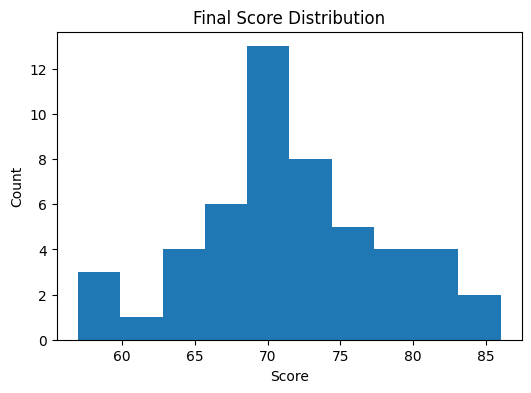

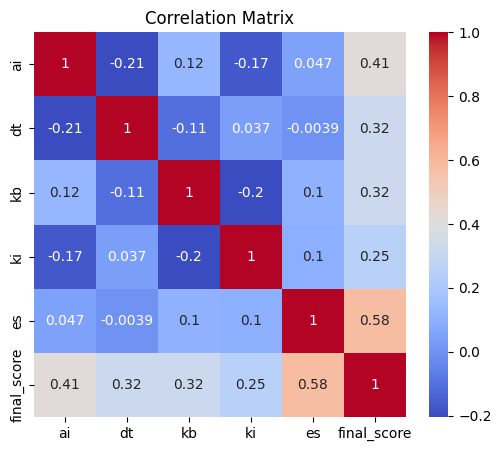

MSE: 31.055920000000032
MAE: 4.444000000000001
R2: 0.5102362403406397


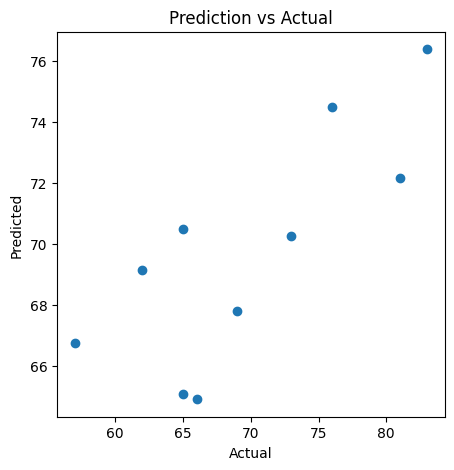

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

rows = []

for i in range(50):
    ai = np.random.randint(50, 100)
    dt = np.random.randint(50, 100)
    kb = np.random.randint(50, 100)
    ki = np.random.randint(50, 100)
    es = np.random.randint(40, 100)

    # final score (realga yaqin formula)
    final = int(
        0.22 * ai +
        0.20 * dt +
        0.20 * kb +
        0.20 * ki +
        0.18 * es +
        np.random.randint(-5, 5)
    )

    rows.append([ai, dt, kb, ki, es, final])

data = pd.DataFrame(rows, columns=["ai", "dt", "kb", "ki", "es", "final_score"])

data.head()

print("Before:", len(data))

data = data[
    (data["ai"] >= 0) & (data["ai"] <= 100) &
    (data["dt"] >= 0) & (data["dt"] <= 100) &
    (data["kb"] >= 0) & (data["kb"] <= 100) &
    (data["ki"] >= 0) & (data["ki"] <= 100) &
    (data["es"] >= 0) & (data["es"] <= 100) &
    (data["final_score"] >= 0) & (data["final_score"] <= 100)
]

print("After:", len(data))

data.describe()

plt.figure(figsize=(6,4))
plt.hist(data["final_score"], bins=10)
plt.title("Final Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

from sklearn.model_selection import train_test_split

X = data[["ai", "dt", "kb", "ki", "es"]]
y = data["final_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual")
plt.show()